# On Sky Calibrations

To fit for the diattenuation of M3, you can use the `pyPolCal.on_sky` module to perform aperture photometry and write a CSV. After this, you can perform a wavelength and global fit in the same way done for the internal cals.

# Step 1: Perform Aperture Photometry and Write CSV
The function `write_fits_info_to_csv_psf` has lots of different inputs, which you can see descriptions of in the docstring. The main choices you have are whether or not to do background subtraction with an annulus and whether to use a constant aperture size or fit for one using 3X the fitted FWHM of the PSF. It will allow you to plot the apertures of every x data point with the `plot_every_x` argument. There will be 22 possible plots for each exposure, so do not plot every one! (I crashed my computer doing this).

I'm going to fit for a FWHM and use that for aperture photometry, and I'm going to use a background annulus that is 5 pixels wider than the fitted FWHM. 

In [ ]:
from pyPolCal.on_sky import write_fits_info_to_csv_psf
from pathlib import Path
from importlib.resources import files

# HD293396
cubedir = Path('/home/shared/exoserver/CHARIS-cals/Nov-onsky/HD293396/cubes/skysub')
rawdir = Path('/home/shared/exoserver/CHARIS-cals/Nov-onsky/HD293396/raw')

centroid_guesses = ([66,85],[131,117]) 
boxsize = 45 # Box size in pixels to search for the centroid
aper_radii = [25,25]
annuli_radii = ([25,30],[25,30])

for wavelength_bin in range(22):
    fname = f'bin{wavelength_bin}.csv'
    csvpath = Path('/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_nbs/HD293396') / fname
    write_fits_info_to_csv_psf(cubedir,csvpath,centroid_guesses=centroid_guesses,
                               box_size=boxsize, raw_cube_path=rawdir, auto_annuli=True, max_fwhm=[15,15],
                               wavelength_bin=wavelength_bin,plot_every_x=300,mask=False)

# the titles on the output plots are the frame numbers 

In [2]:
# remove last row from each csv
import pandas as pd
for bin in range(22):
    fname = f'bin{bin}.csv'
    csvpath = Path('/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_nbs/HD293396') / fname
    df = pd.read_csv(csvpath)
    df = df[:-1] # remove last row
    df.to_csv(csvpath, index=False)


Common bug: double check the CSV to make sure it has an integer number of HWP cycles

# Step 2: Set Up Model For Rest of Optical Path

I'm doing this using the previous fit.

In [1]:
from pyPolCal.csv_tools import model_data

wavelength_fits_df = model_data('wavelength_fit_results') 
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()



/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 3: Fit by Wavelength

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

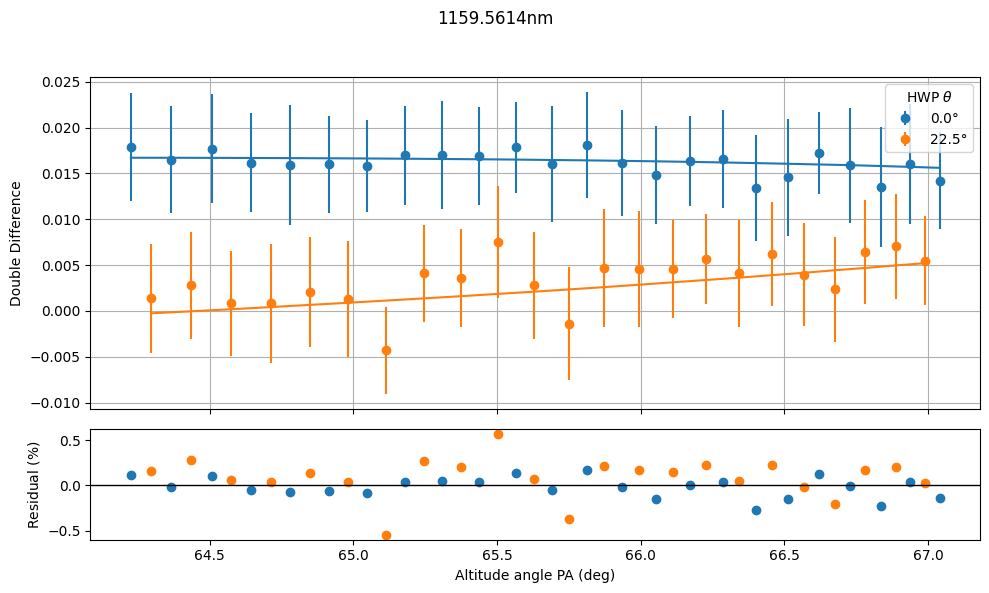

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

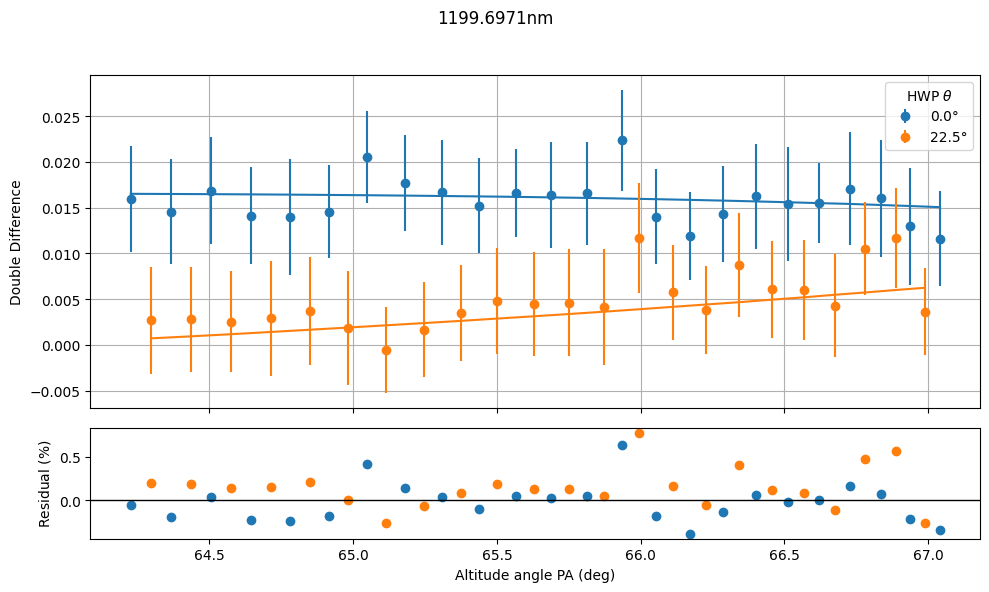

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

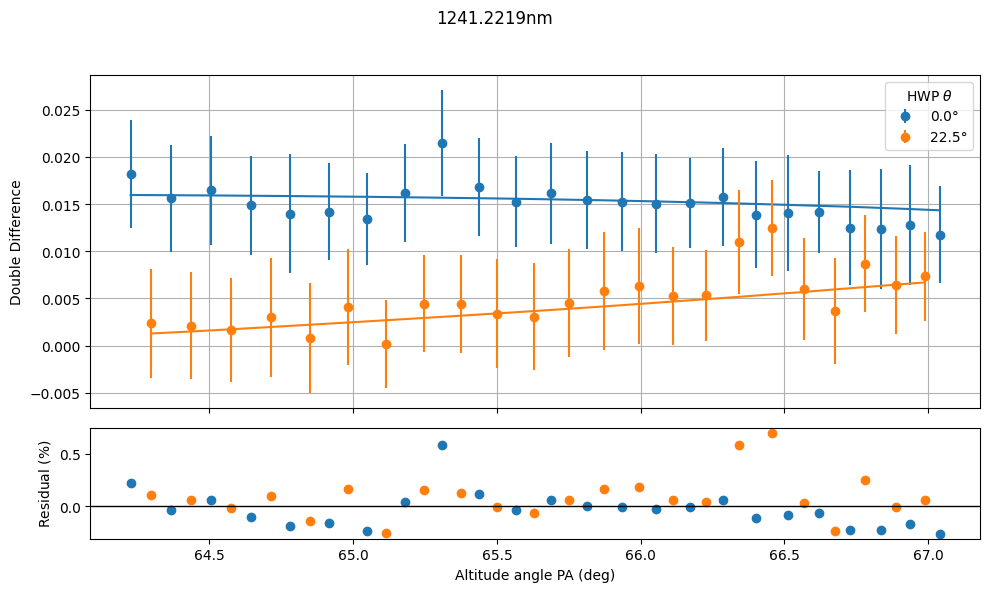

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

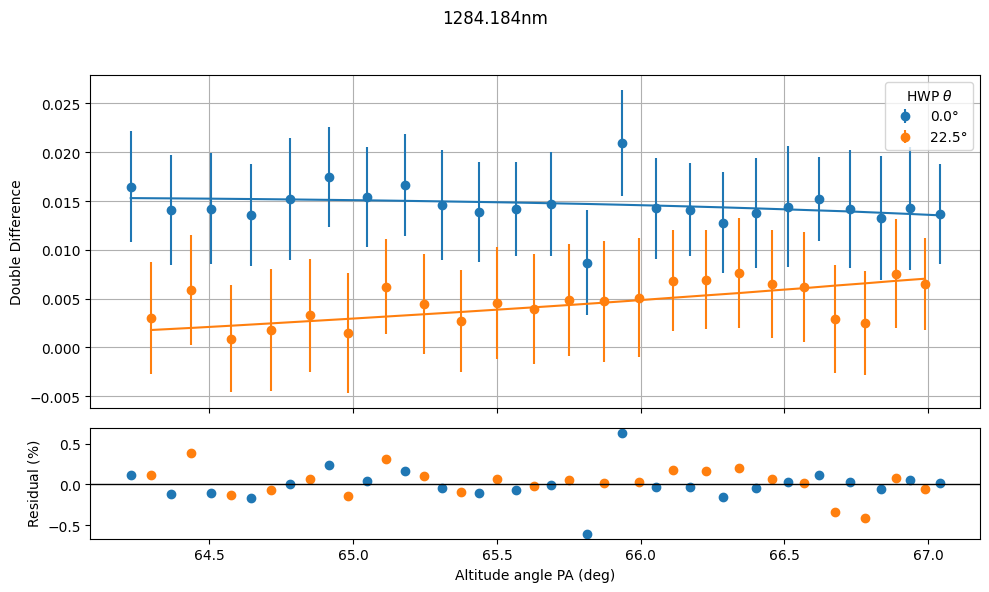

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

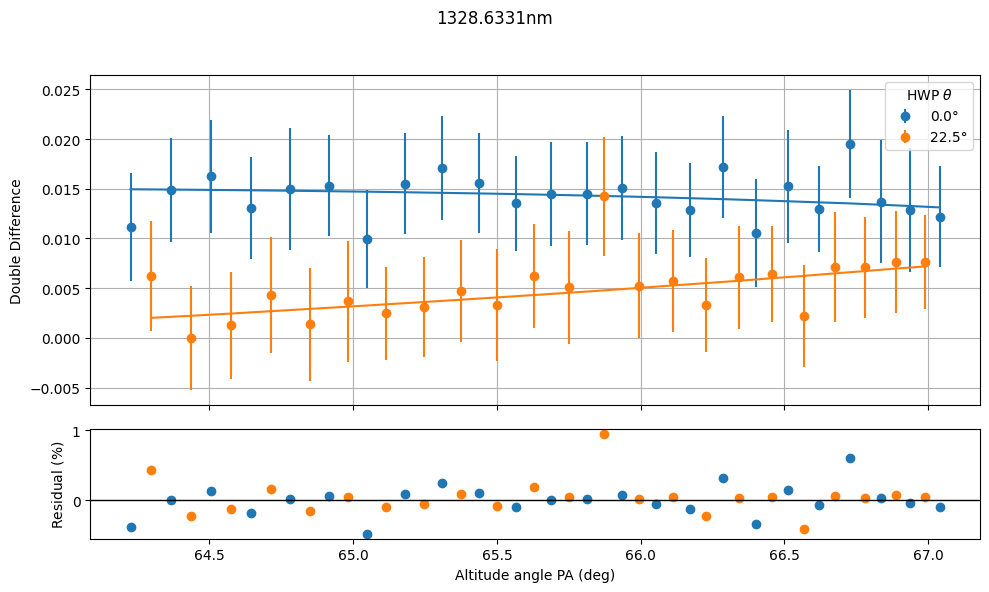

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

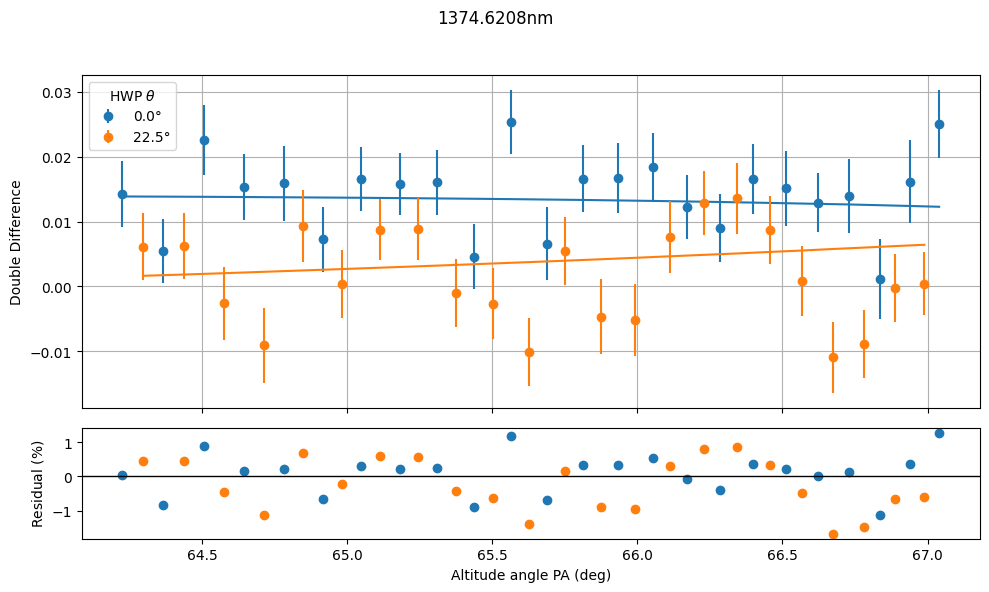

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

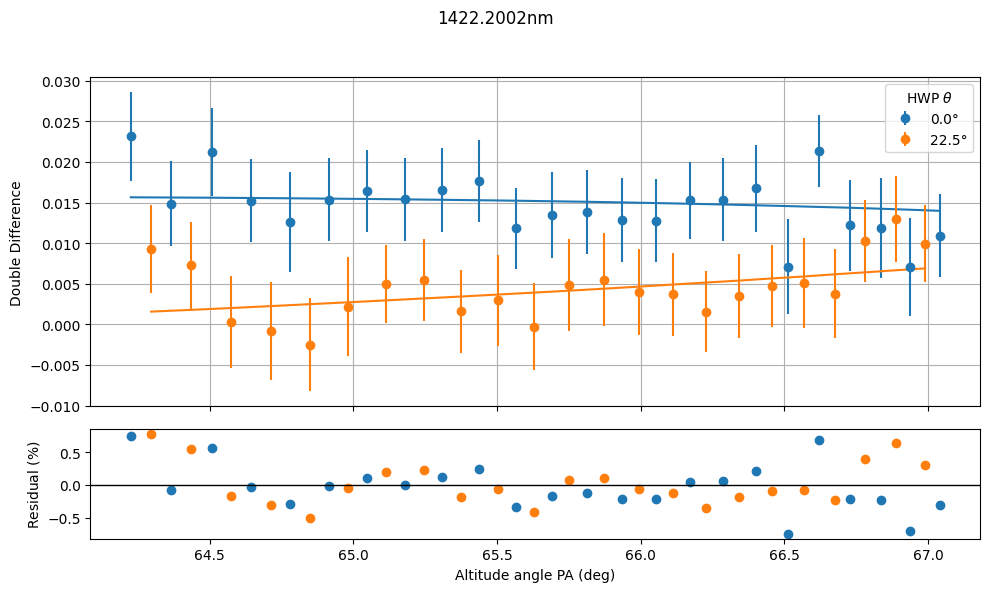

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

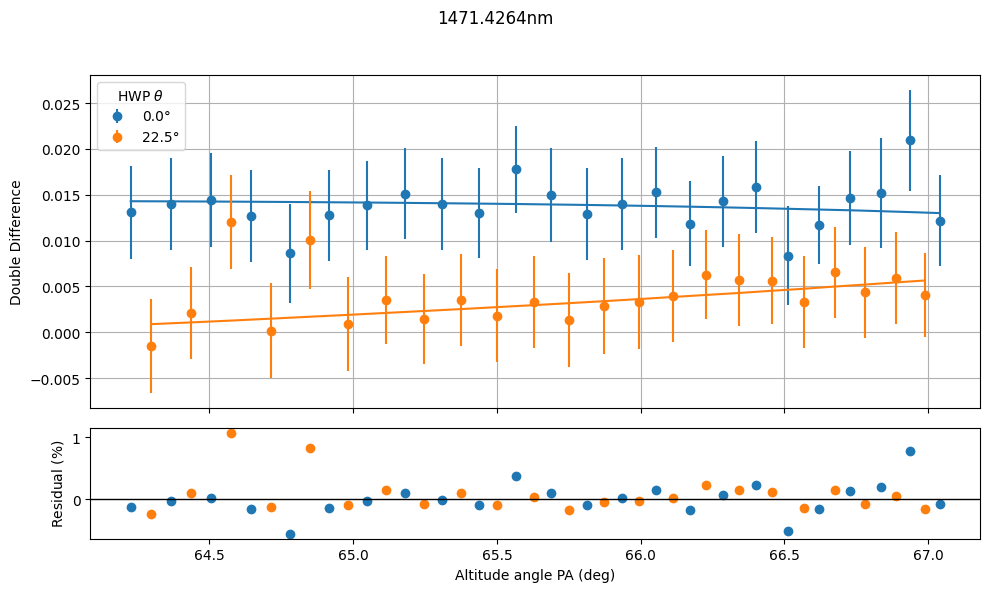

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

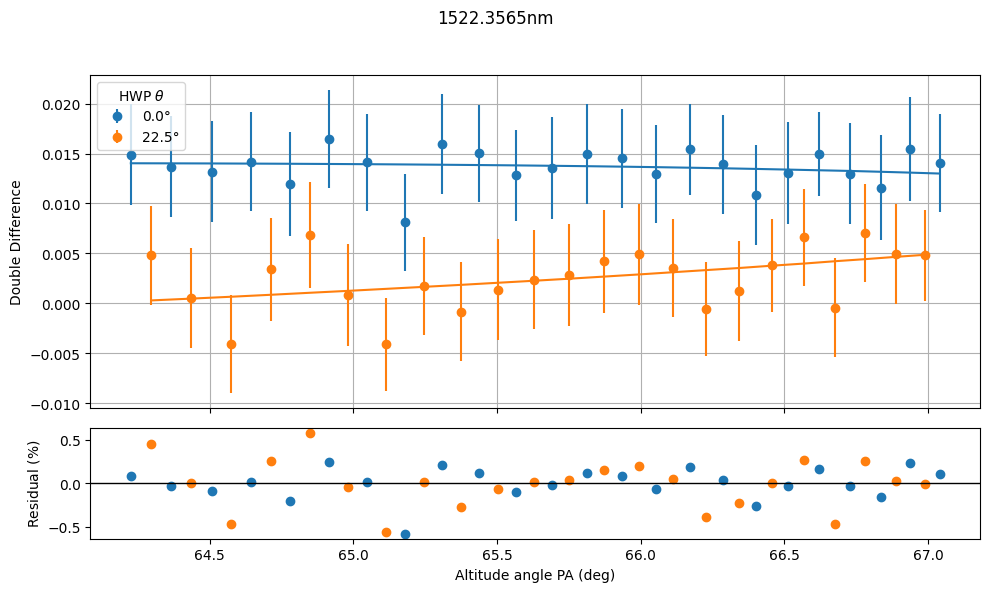

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

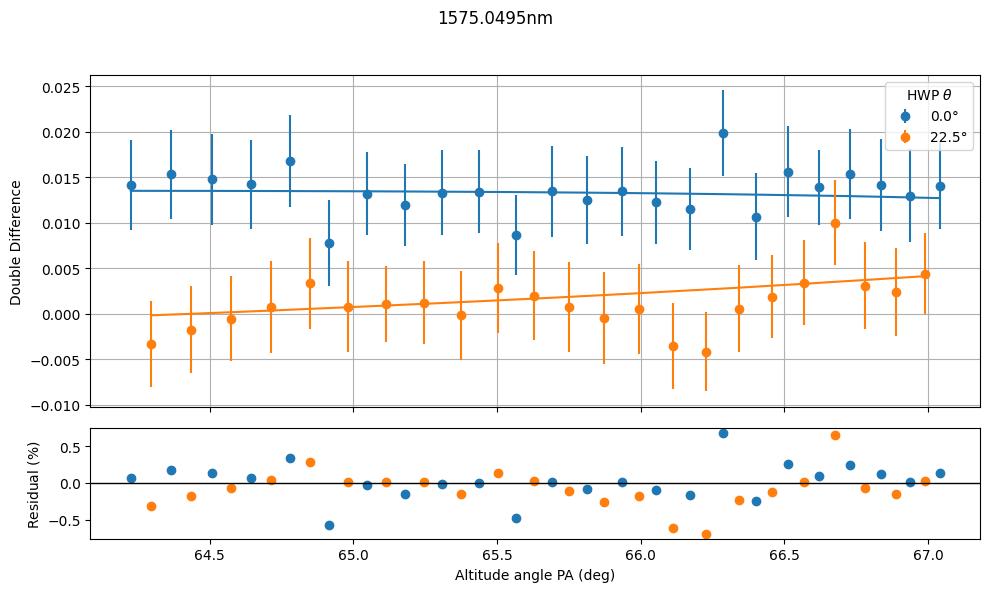

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

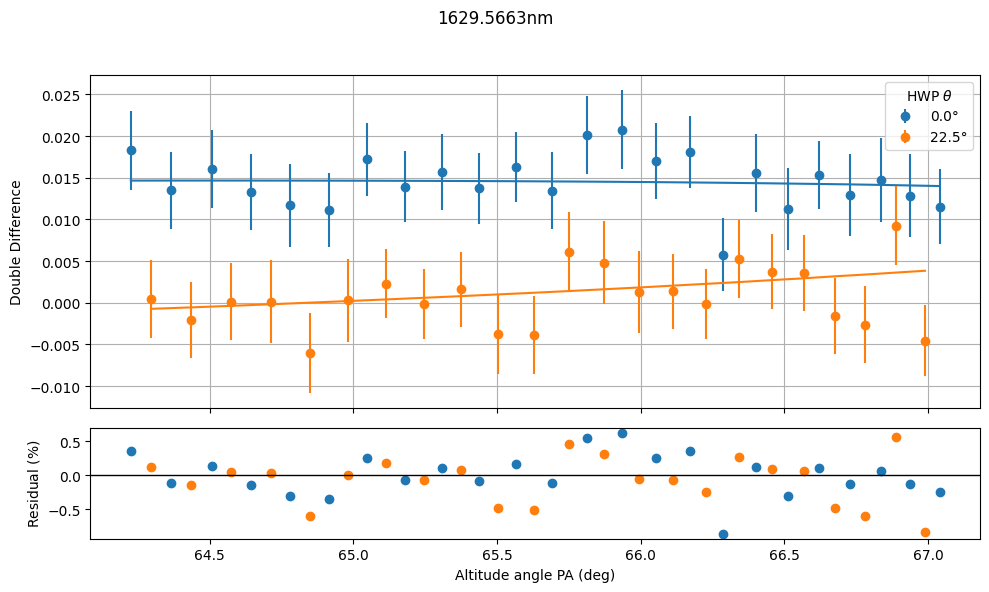

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

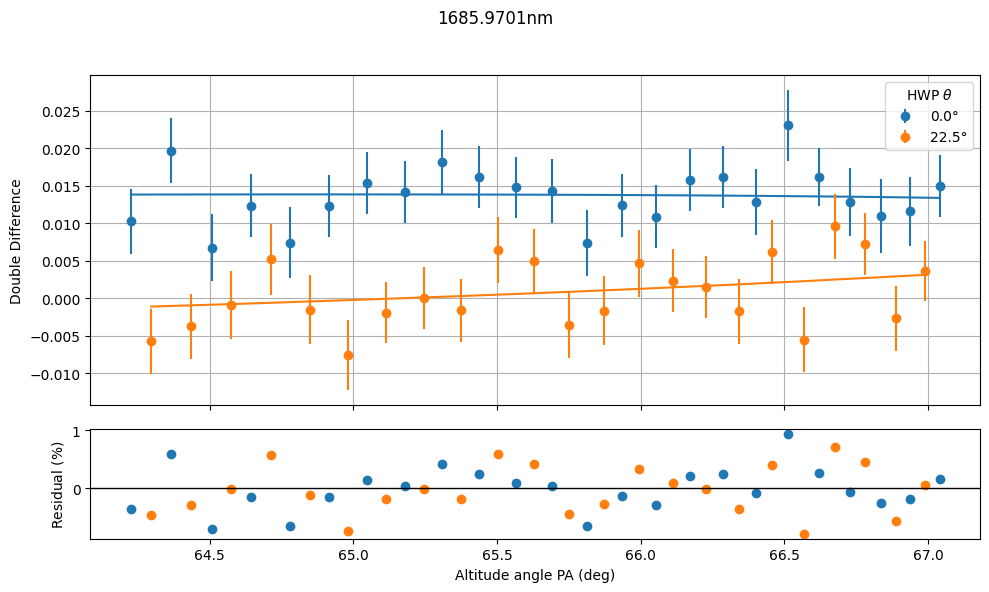

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

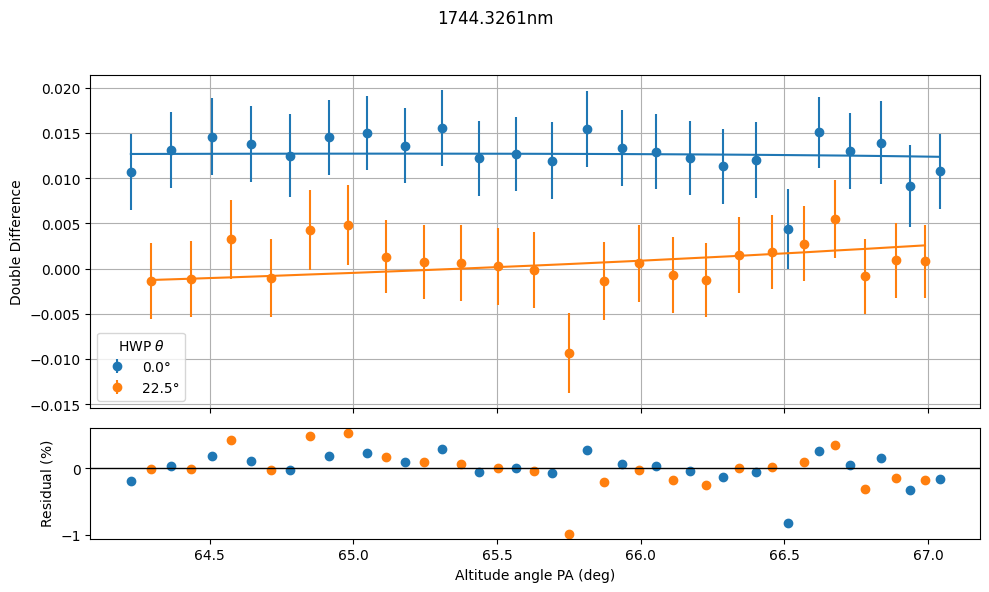

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

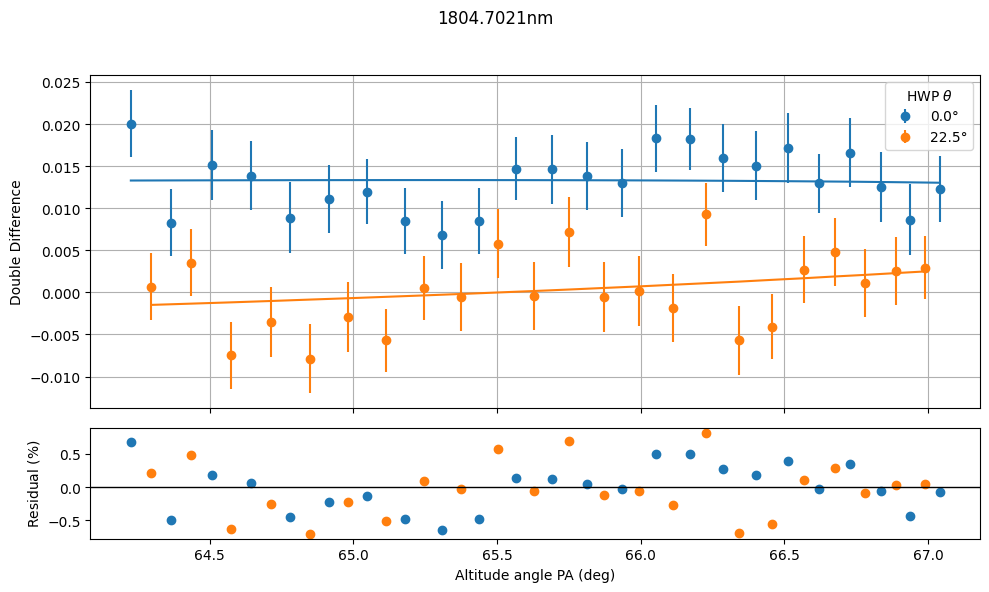

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

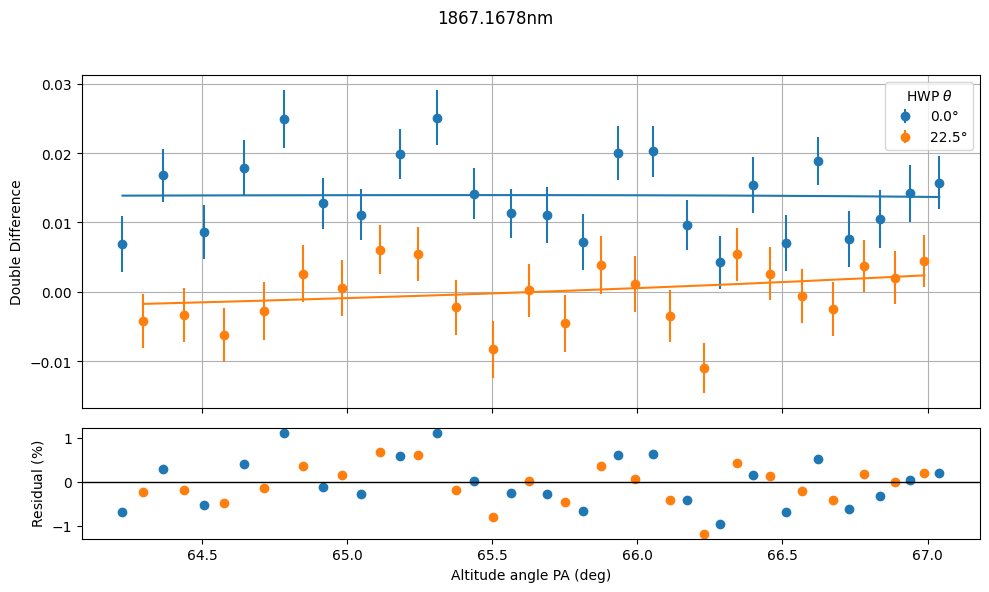

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

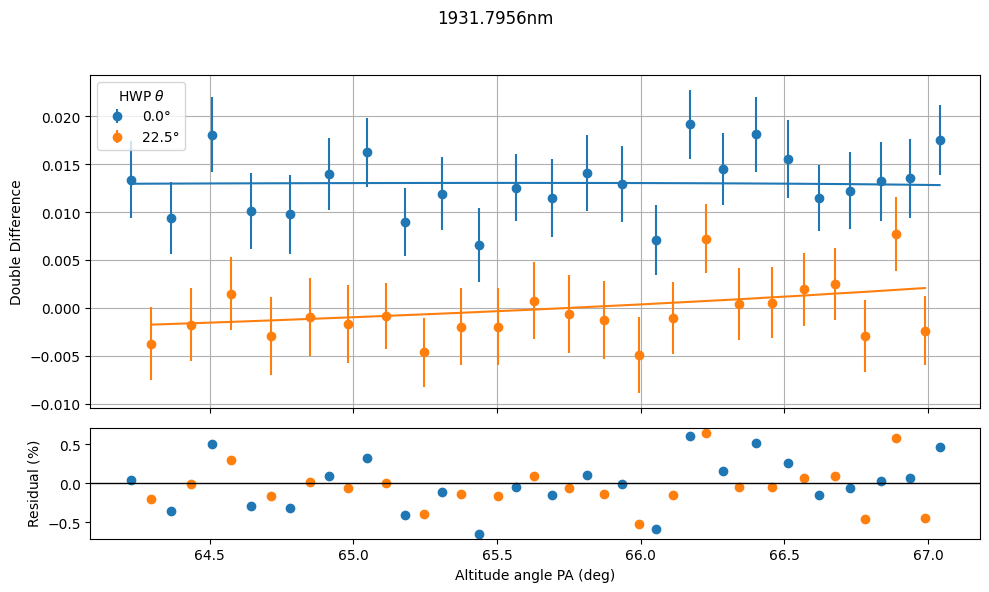

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

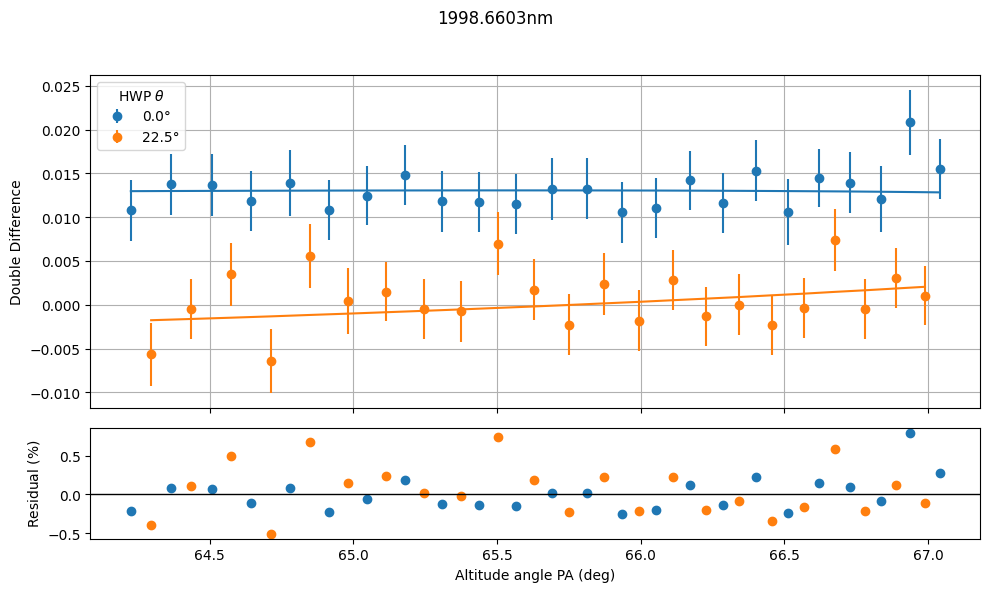

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

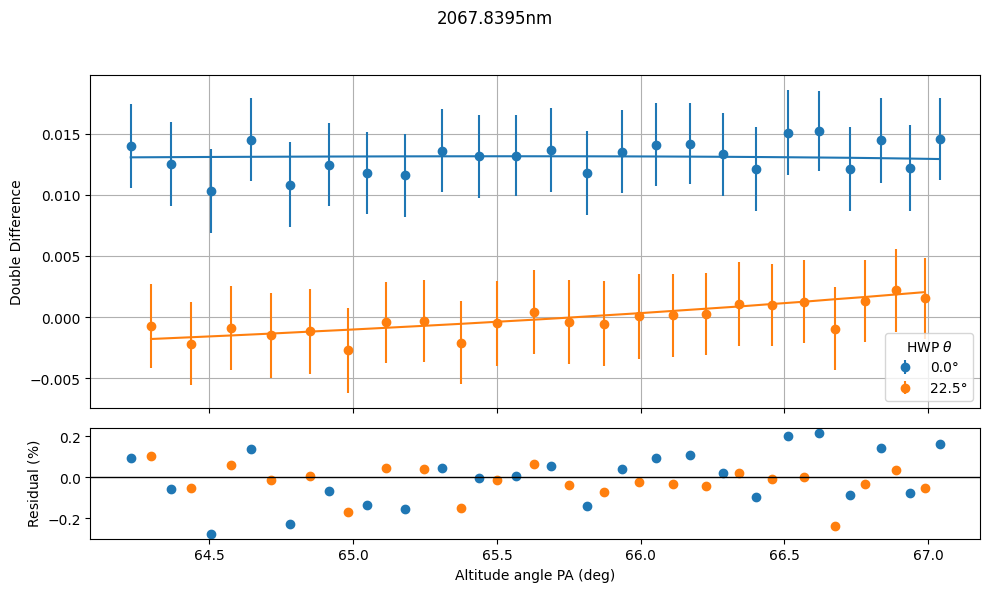

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

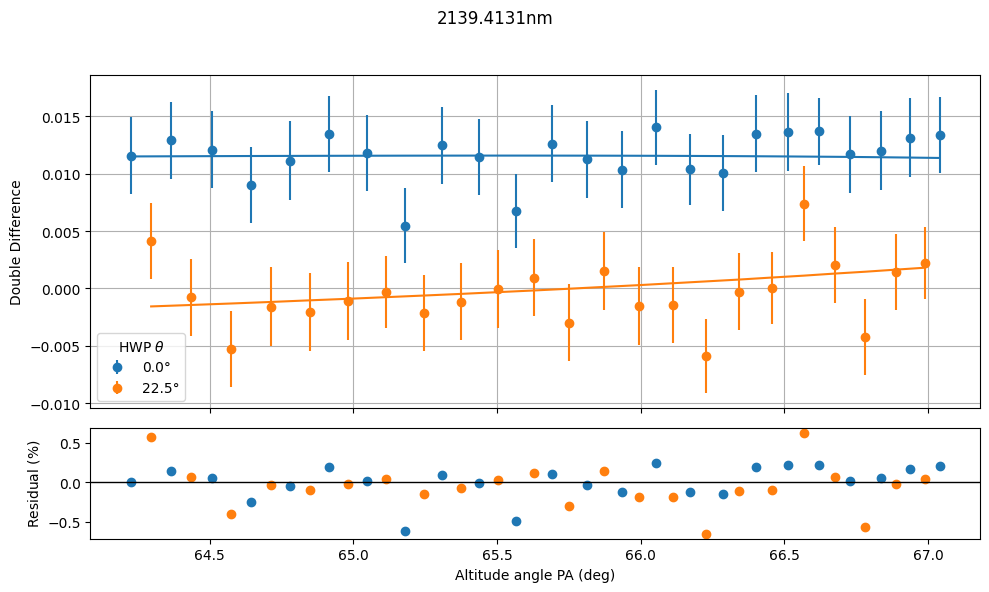

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

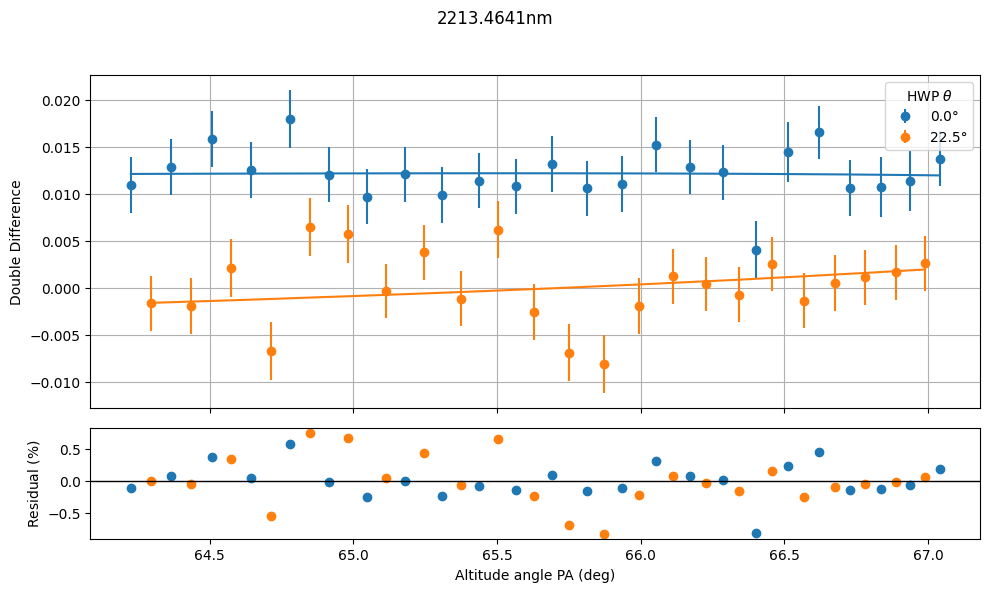

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

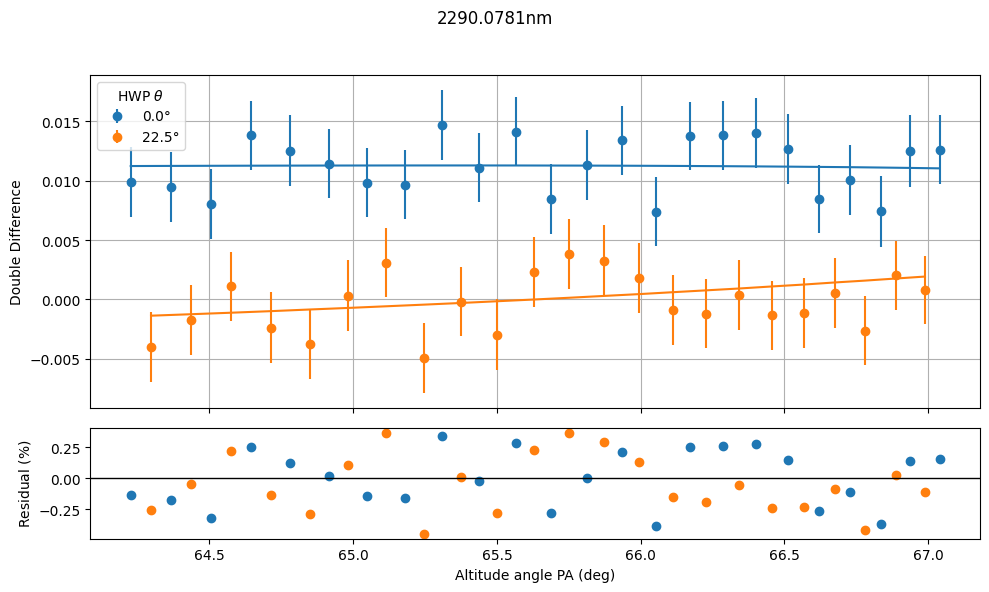

[{'hwp': {'theta': 79.0}, 'image_rotator': {'theta': 97.03698}, 'altitude_rot': {'pa': -67.0400338}, 'parang_rot': {'pa': 24.081946297674342}}, {'hwp': {'theta': 124.1}, 'image_rotator': {'theta': 97.01482}, 'altitude_rot': {'pa': -67.01509507}, 'parang_rot': {'pa': 24.2169465418744}}, {'hwp': {'theta': 101.62}, 'image_rotator': {'theta': 96.9561}, 'altitude_rot': {'pa': -66.98936139}, 'parang_rot': {'pa': 24.351931406002127}}, {'hwp': {'theta': 146.68}, 'image_rotator': {'theta': 96.98731}, 'altitude_rot': {'pa': -66.96398804}, 'parang_rot': {'pa': 24.482859559185144}}, {'hwp': {'theta': 79.2}, 'image_rotator': {'theta': 96.97554}, 'altitude_rot': {'pa': -66.93833461}, 'parang_rot': {'pa': 24.61602993395442}}, {'hwp': {'theta': 124.23}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.91253914}, 'parang_rot': {'pa': 24.749200522698622}}, {'hwp': {'theta': 101.79}, 'image_rotator': {'theta': 96.95465}, 'altitude_rot': {'pa': -66.88680568}, 'parang_rot': {'pa': 24.882618

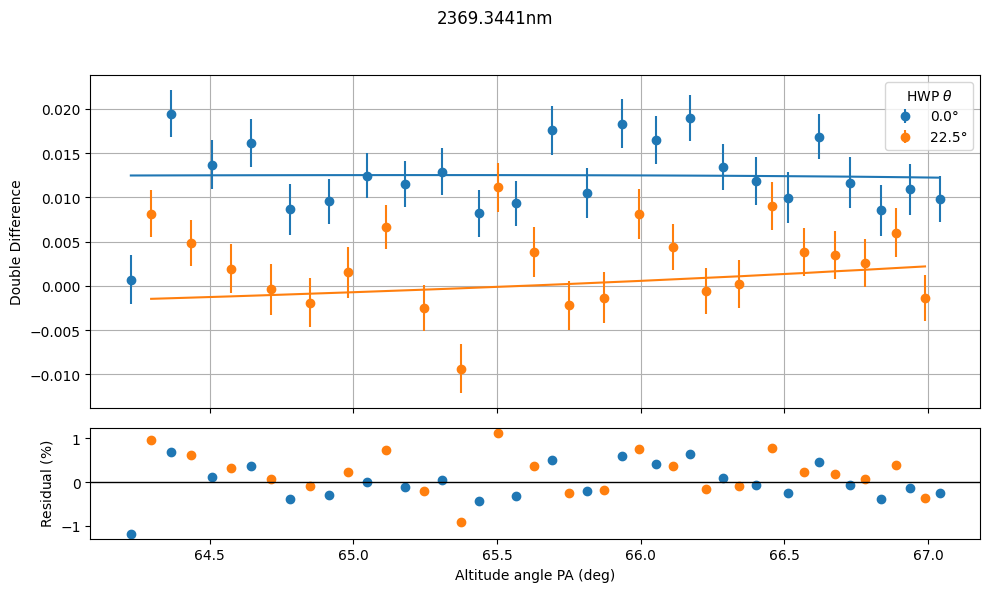

In [2]:
from pyPolCal.csv_tools import read_csv 
from pyPolCal.utils import * 
from pyPolCal.fitting import minimize_system_mueller_matrix, model, process_dataset, process_model, process_errors, update_p0, update_system_mm
from pyPolCal.plotting import plot_data_and_model_alt
from pyPolCal.constants import wavelength_bins # all CHARIS wavelength bins
from pyMuellerMat.physical_models.charis_physical_models import * # Joost 't Hart 2021 physical models
import numpy as np
import json
from importlib.resources import files

s_abss = []
errors = []
for bin in range(22): # 22 wavelength bins

    ############ PREPARING MODEL #############

    # Define the path to the CSV file for the current bin
    fname = f'bin{bin}.csv'
    # going to use HD293396 instead, data seems better
    csvpath = files('pyPolCal.CHARIS.datacsvs.onsky_nbs.HD293396') / fname
    # Read csv
    interleaved_values, interleaved_stds, configuration_list = read_csv(csvpath, mode='m3') # SET M3 MODE
    print(configuration_list)
    # Load in system dictionary

    system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "wollaston_prism_function",
        "properties" : {"beam": 'o', "eta": wollaston_eta[bin]}, 
        "tag": "internal",
        },

        "nbs_rot": {
            "type": "rotator_function",
            "properties": {"pa": 90},
            "tag": "internal",
        },
        "image_rotator" : {
        "type" : "elliptical_retarder_function",
        "properties" : {"delta_theta":-2.331e-02 , 'phi_h': derotator_phi_h[bin], 'phi_45': derotator_phi_45[bin], 'phi_r': derotator_phi_r[bin]}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "general_retarder_function", # Joost 't Hart 2021 HWP model
            "properties" : {"phi": HWP_retardance(wavelength_bins,1.653,1.291)[bin],"delta_theta": -3.807e-02 },
            "tag": "internal",
        },

        "altitude_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        "M3" : {
            "type" : "diattenuator_retarder_function",
            "properties" : {"epsilon":0, "theta": 0, "delta_theta":0},
            "tag": "internal",
        },

        "parang_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
    }
    }

    # Converting system dictionary into system Mueller Matrix object
    system_mm = generate_system_mueller_matrix(system_dict)

    ############ FITTING #############

    # Starting guesses for all parameters, I'm taking mine from the Joost't Hart 2021 physical models
    hwp_retardance = HWP_retardance(wavelength_bins)[bin]
    imr_retardance = IMR_retardance(wavelength_bins)[bin]
    wol_eta = 1 # imperfect wollaston fit, using perfect as starting guess

    # p0 dictionary assigning parameters to their components in the system dictionary
    p0 = {
        "M3": {"epsilon":M3_diattenuation(wavelength_bins)[bin]}
    }

    # Set bounds for each component in order they appear in p0 dictionary
    retardance_bounds = (0,2*np.pi) 
    eta_bounds = (0,1)
    bounds_list = [(-1,1)]

    # Minimize, using process dataset and process model to process everything into double differences
    # Excluding double sums (always do this for CHARIS)
    # Not using aperture errors, works well for our large apertures

    result, new_logl, error = minimize_system_mueller_matrix(p0, system_mm, interleaved_values, 
    configuration_list, errors=interleaved_stds, process_errors=process_errors, process_dataset=process_dataset,process_model=process_model,include_sums=False, bounds = bounds_list,mode='least_squares')
    print(result)
    errors.append(error)

    ########## PLOTTING RESULTS ##########

    # Update p0 and system mueller matrix with fits
    update_p0(p0, result.x)
    p0_values, p0_keywords = parse_configuration(p0) # parsing updated p0 dictionary
    updated_system_mm = update_system_mm(p0_values, p0_keywords, system_mm)

    # Plot using instructions in plotting_a_model.ipynb
    interleaved_modeled = model(p0_values, p0_keywords, updated_system_mm, configuration_list, 
                                process_model=process_model,s_in=[1,0,0,0])

    # Inputting wavelength to use wavelength as the title
    plot_data_and_model_alt(interleaved_values, interleaved_modeled, configuration_list, interleaved_stds=interleaved_stds,
                                    wavelength=wavelength_bins[bin], include_sums=False)

    ########## CALCULATE S_REL ############

    # Processing single diffs/sums into double diffs/sums
    data_dd = process_dataset(interleaved_values)[::2] # only taking diffs

    # Only taking diffs                                              
    model_dd = interleaved_modeled[::2]

    # Converting resiudals to a percent
    residuals = data_dd*100 - model_dd*100

    # Calculating s_abs
    s_abs = np.sqrt(np.sum(residuals**2)/(len(data_dd)-len(p0_values)))
    s_abss.append(s_abs)


    ######### SAVING MODEL ###########

    updated_p0_path = f'wavelength_fit_results_on_sky/bin{bin}.json'
    with open (updated_p0_path, 'w') as f:
        json.dump(p0, f, indent=4)

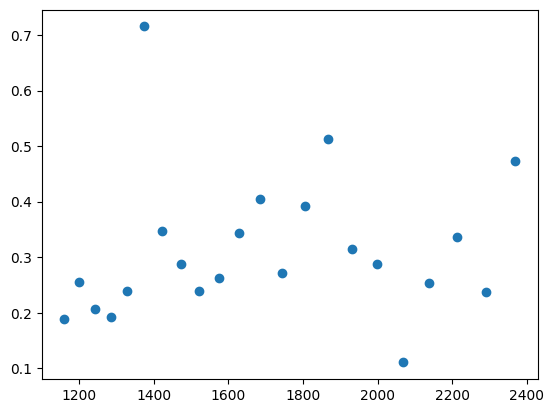

In [3]:
# Plotting s_abs to see the goodness of fit

plt.scatter(wavelength_bins, s_abss)

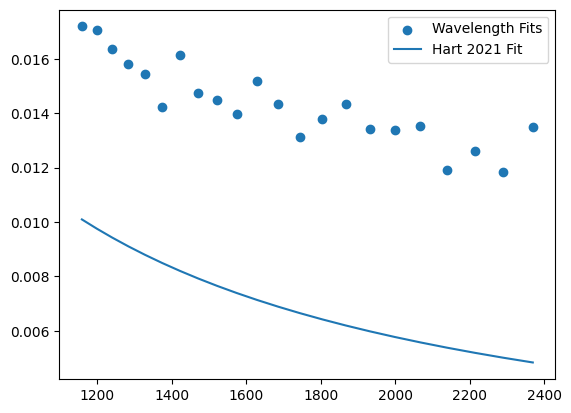

In [7]:
# plotting M3 diattenuation against an old M3 physical model fit
from pyPolCal.csv_tools import model_data
jsondir = 'wavelength_fit_results_on_sky'
df = model_data(jsondir)
diat = df['M3_epsilon'].to_numpy()
plt.scatter(wavelength_bins, diat)
plt.plot(wavelength_bins, M3_diattenuation(wavelength_bins,m1=2.104, b1=14.2, m2=2.1,b2=13.2))
plt.legend(['Wavelength Fits','Hart 2021 Fit'])